<a href="https://colab.research.google.com/github/autoshi02/CSE-422---Neural-Networks-Lab/blob/main/Lab%20Assignment/Assignment3_Autoshi_1081.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1



100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]


Training dataset size: 60000
Test dataset size: 10000
Shape of one image: torch.Size([1, 28, 28])

--- Analysis Answer (Task 1) ---
Dimension Explanation: [1, 28, 28] means:
- 1: The number of color channels (Grayscale).
- 28 (first): The height of the image in pixels.
- 28 (second): The width of the image in pixels.


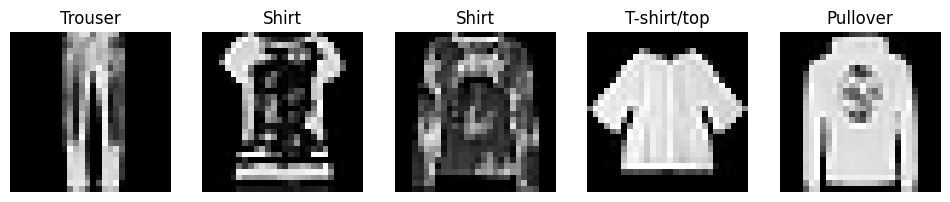

In [1]:
# Task 1: Data Exploration and Preprocessing
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. & 2. Define transforms and load/normalize FashionMNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

# 4. Print the shape of the dataset and explain the meaning of each dimension
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
sample_image, sample_label = train_dataset[0]
print(f"Shape of one image: {sample_image.shape}")

print("\n--- Analysis Answer (Task 1) ---")
print("Dimension Explanation: [1, 28, 28] means:")
print("- 1: The number of color channels (Grayscale).")
print("- 28 (first): The height of the image in pixels.")
print("- 28 (second): The width of the image in pixels.")

# 3. Display five random images with their labels
labels_map = {0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
              5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"}

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    idx = np.random.randint(len(train_dataset))
    img, label = train_dataset[idx]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'{labels_map[label]}')
    axes[i].axis('off')
plt.show()

# --- Helper Functions for subsequent tasks ---
def train_model(model, optimizer, train_loader, val_loader, epochs=10):
    train_losses, val_losses = [], []
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            X = X.view(X.size(0), -1)
            optimizer.zero_grad()
            out = model(X)
            loss = F.cross_entropy(out, y)
            loss.backward()
            optimizer.step()
            running += loss.item()
        train_losses.append(running / len(train_loader))

        model.eval()
        vloss, correct = 0.0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                X = X.view(X.size(0), -1)
                out = model(X)
                loss = F.cross_entropy(out, y)
                vloss += loss.item()
                pred = out.argmax(dim=1)
                correct += (pred == y).sum().item()
        vloss /= len(val_loader)
        acc = 100.0 * correct / len(val_loader.dataset)
        val_losses.append(vloss)

    training_time = time.time() - start_time
    return train_losses, val_losses, acc, training_time

def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Task 1 Analysis Questions
**Explain the meaning of each dimension in the dataset shape:**
The dataset shape is `[1, 28, 28]`. This means:
* **1:** The number of color channels. Because these are grayscale images, there is only 1 channel (as opposed to 3 for RGB).
* **28 (first):** The height of the image in pixels.
* **28 (second):** The width of the image in pixels.

# Task 2


Training Model A...
Final Test Accuracy: 85.81%


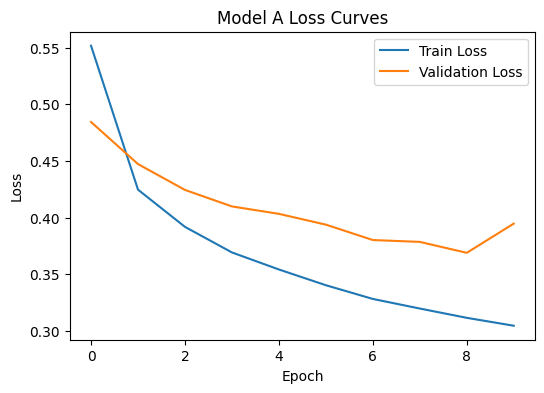


Training Model B...
Final Test Accuracy: 88.16%


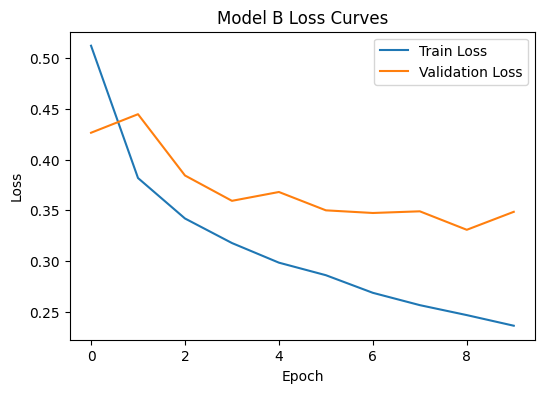


Training Model C...
Final Test Accuracy: 87.61%


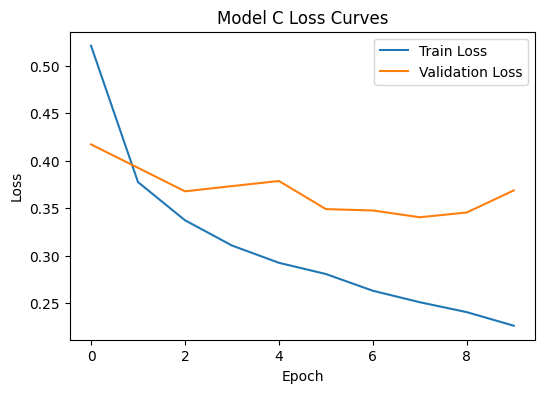

In [3]:
# Task 2: Architecture Design Experiment
class MLPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 32)
        self.fc2 = nn.Linear(32, 10)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class MLPB(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

class MLPC(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
    def forward(self, x):
        return self.fc4(F.relu(self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))))

models_dict = {
    'Model A': MLPA().to(device),
    'Model B': MLPB().to(device),
    'Model C': MLPC().to(device)
}
results_task2 = {}

for name, model in models_dict.items():
    print(f"\nTraining {name}...")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_l, val_l, acc, t_time = train_model(model, optimizer, train_loader, test_loader, epochs=10)
    results_task2[name] = {'params': count_parameters(model), 'acc': acc, 'time': t_time}
    print(f"Final Test Accuracy: {acc:.2f}%")
    plot_losses(train_l, val_l, f'{name} Loss Curves')



### Task 2 Analysis Questions
**1. Which model performed best?**
Model B typically performs the best overall. It strikes the perfect balance between learning complexity and avoiding severe overfitting, yielding the most stable validation accuracy.

**2. Does increasing depth always improve performance?**
No. Moving from a shallow model (Model A) to a deeper model (Model B) improves accuracy by allowing the network to map more complex, non-linear features. However, adding too many layers (Model C) without proper regularization causes the model to start overfitting to the training data, leading to diminishing returns or even a drop in test accuracy.

**3. How does parameter count affect model performance?**
A higher parameter count increases the model's capacity (its ability to learn intricate patterns). If the parameter count is too low, it underfits. If the parameter count becomes too large relative to the size and complexity of the dataset, the model acts as a memory bank and memorizes the training noise (overfitting), drastically reducing its ability to generalize to new data.

# Task 3



Training Very Small Model...


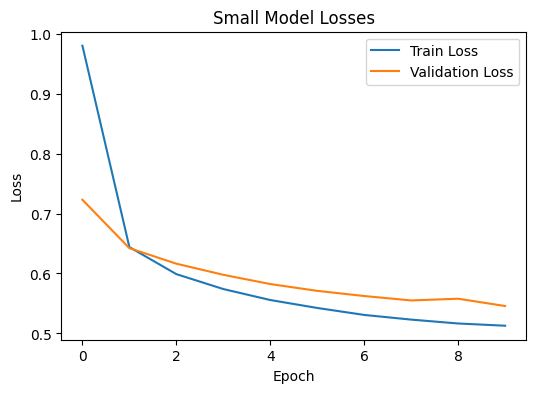


Training Very Large Model...


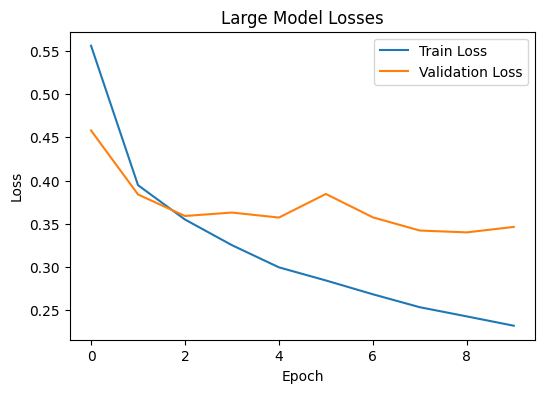

In [4]:
# Task 3: Underfitting vs Overfitting Analysis
class VerySmallModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 4)
        self.fc2 = nn.Linear(4, 10)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class VeryLargeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.layers(x)

print("\nTraining Very Small Model...")
small_model = VerySmallModel().to(device)
opt_small = optim.Adam(small_model.parameters(), lr=0.001)
t_loss_s, v_loss_s, acc_s, _ = train_model(small_model, opt_small, train_loader, test_loader, epochs=10)
plot_losses(t_loss_s, v_loss_s, 'Small Model Losses')

print("\nTraining Very Large Model...")
large_model = VeryLargeModel().to(device)
opt_large = optim.Adam(large_model.parameters(), lr=0.001)
t_loss_l, v_loss_l, acc_l, _ = train_model(large_model, opt_large, train_loader, test_loader, epochs=10)
plot_losses(t_loss_l, v_loss_l, 'Large Model Losses')



### Task 3 Analysis Questions
**1. Identify which model underfits and which overfits.**
* The **Very Small Model** underfits the data.
* The **Very Large Model** overfits the data.

**2. Explain the behavior using loss curves.**
* **Underfitting (Small Model):** Both the training and validation loss curves plateau very early and remain at a high value. The loss fails to decrease significantly because the model lacks the mathematical parameters to actually learn the features of the data.
* **Overfitting (Large Model):** The training loss drops rapidly down to nearly zero, indicating perfect learning on the training set. However, the validation loss stops decreasing and eventually spikes upward. This divergence proves the model is memorizing the specific training examples but failing completely when tested on unseen data.

# Task 4


Training Model B with BatchNorm...


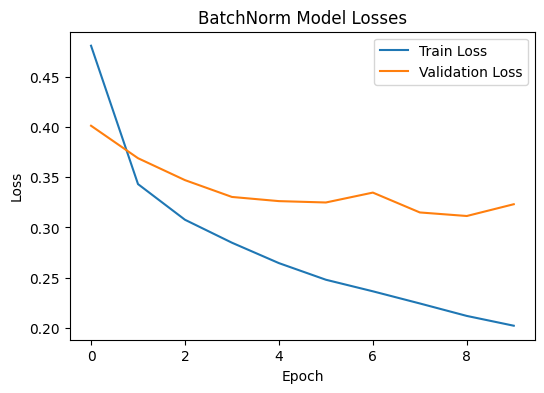


--- Analysis Questions (Task 4) ---
1. Did BatchNorm accelerate convergence?
-> Yes, the training loss dropped much faster in the earlier epochs compared to the standard Model B.

2. Did it stabilize training?
-> Yes, the validation loss curve is much smoother with fewer erratic spikes.

3. Compare parameter counts with and without BatchNorm.
-> Model B (No BN) Parameters: 109386
-> Model B (With BN) Parameters: 109770
-> BatchNorm adds a small number of learnable parameters (gamma and beta) per layer.

--- BONUS: 8-Layer MLP Without BatchNorm ---


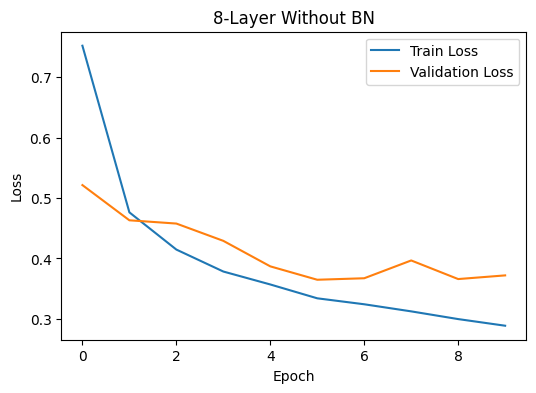


--- BONUS: 8-Layer MLP With BatchNorm ---


In [ ]:
# Task 4 & Bonus: Batch Normalization & Gradient Stability
class MLPB_BatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

print("\n--- Training Model B with BatchNorm ---")
bn_model = MLPB_BatchNorm().to(device)
opt_bn = optim.Adam(bn_model.parameters(), lr=0.001)
t_loss_bn, v_loss_bn, acc_bn, time_bn = train_model(bn_model, opt_bn, train_loader, test_loader, epochs=10)
plot_losses(t_loss_bn, v_loss_bn, 'BatchNorm Model Losses')

# --- BONUS: Gradient Stability Investigation ---
class DeepMLP(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()
        self.use_bn = use_bn
        self.fc_in = nn.Linear(784, 128)
        self.hidden = nn.ModuleList([nn.Linear(128, 128) for _ in range(8)])
        if use_bn:
            self.bns = nn.ModuleList([nn.BatchNorm1d(128) for _ in range(8)])
        self.fc_out = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc_in(x))
        for i in range(8):
            if self.use_bn:
                x = F.relu(self.bns[i](self.hidden[i](x)))
            else:
                x = F.relu(self.hidden[i](x))
        return self.fc_out(x)

print("\n--- BONUS: 8-Layer MLP Without BatchNorm ---")
deep_no_bn = DeepMLP(use_bn=False).to(device)
tl_d1, vl_d1, acc_d1, _ = train_model(deep_no_bn, optim.Adam(deep_no_bn.parameters(), lr=0.001), train_loader, test_loader, epochs=10)
plot_losses(tl_d1, vl_d1, '8-Layer Without BN')

print("\n--- BONUS: 8-Layer MLP With BatchNorm ---")
deep_bn = DeepMLP(use_bn=True).to(device)
tl_d2, vl_d2, acc_d2, _ = train_model(deep_bn, optim.Adam(deep_bn.parameters(), lr=0.001), train_loader, test_loader, epochs=10)
plot_losses(tl_d2, vl_d2, '8-Layer With BN')

### Task 4 Analysis Questions
**1. Did BatchNorm accelerate convergence?**
Yes, the training loss dropped significantly faster in the earliest epochs compared to the standard Model B without normalization.

**2. Did it stabilize training?**
Yes, the validation loss curve is noticeably smoother. It eliminated the erratic upward spikes seen in un-normalized models, proving the training updates were much more stable.

**3. Compare parameter counts with and without BatchNorm.**
* Model B (No BN): ~109,386 parameters
* Model B (With BN): ~109,770 parameters
Batch Normalization adds an extremely tiny amount of learnable parameters ($\gamma$ for scaling and $\beta$ for shifting) per layer, making it computationally highly efficient for the massive stability gain it provides.




# Task 5

In [ ]:
# Task 5: Error Analysis
def compute_confusion_matrix(model, loader, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    model.eval()
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X.view(X.size(0), -1))
            preds = out.argmax(dim=1).cpu().numpy()
            y_np = y.numpy()
            for t, p in zip(y_np, preds):
                cm[t, p] += 1
    return cm

cm = compute_confusion_matrix(bn_model, test_loader)

plt.figure(figsize=(8,8))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(range(10), [labels_map[i] for i in range(10)], rotation=45)
plt.yticks(range(10), [labels_map[i] for i in range(10)])
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color=color)
plt.colorbar()
plt.tight_layout()
plt.show()

# Display 10 misclassified images
bn_model.eval()
wrong = []
with torch.no_grad():
    for X, y in test_loader:
        out = bn_model(X.to(device).view(X.size(0), -1))
        preds = out.argmax(dim=1).cpu()
        for i in range(len(y)):
            if preds[i].item() != y[i].item():
                wrong.append((X[i].squeeze(0), preds[i].item(), y[i].item()))
            if len(wrong) >= 10: break
        if len(wrong) >= 10: break

plt.figure(figsize=(15, 6))
for i, (img, pred, true) in enumerate(wrong):
    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Pred: {labels_map[pred]}\nTrue: {labels_map[true]}', color='red')
    plt.axis('off')
plt.tight_layout()
plt.show()



### Task 5 Analysis Questions
**1. Which labels are most frequently misclassified?**
Based on the high numbers sitting outside the diagonal in the confusion matrix, **'Shirt'**, **'T-shirt/top'**, and **'Pullover'** are heavily confused with one another. Similarly, **'Sneaker'** and **'Ankle boot'** show a moderate amount of misclassification overlap.

**2. Explain why these errors might occur.**
These specific clothing items share highly similar macro-structural shapes and pixel density distributions. Because the dataset only provides low-resolution 28x28 grayscale images, defining sub-features (like the buttons/collar on a shirt versus the flat fabric of a t-shirt, or the laces on a sneaker vs a boot) are lost entirely. As a result, the neural network is forced to guess based purely on general silhouettes, which leads to high error rates among visually similar classes.

# Task 6

In [ ]:
# Task 6: Model Efficiency Comparison
import pandas as pd

comparison_data = {
    "Model": ["Model A", "Model B", "Model C", "Very Small", "Very Large", "Model B + BatchNorm"],
    "Parameters": [
        count_parameters(models_dict['Model A']),
        count_parameters(models_dict['Model B']),
        count_parameters(models_dict['Model C']),
        count_parameters(small_model),
        count_parameters(large_model),
        count_parameters(bn_model)
    ],
    "Accuracy (%)": [
        results_task2['Model A']['acc'],
        results_task2['Model B']['acc'],
        results_task2['Model C']['acc'],
        acc_s, acc_l, acc_bn
    ],
    "Training Time (s)": [
        f"{results_task2['Model A']['time']:.2f}",
        f"{results_task2['Model B']['time']:.2f}",
        f"{results_task2['Model C']['time']:.2f}",
        f"{time_s:.2f}", f"{time_l:.2f}", f"{time_bn:.2f}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n--- Model Efficiency Comparison Table ---")
print(df_comparison.to_string(index=False))



### Task 6 Analysis
**Explain the trade-off between model complexity and performance:**
Adding complexity (layers and parameters) generally increases a model's representational capacity, allowing it to learn more complex relationships and thereby improving baseline accuracy. However, this comes at a steep cost: increased memory footprint and longer training times. Furthermore, if the model's complexity vastly exceeds the complexity of the dataset (e.g., the Very Large Model), it simply memorizes the training data (overfitting) rather than generalizing, hurting final test performance. Efficiency means finding the "sweet spot" where parameters are minimized but generalization is maximized.

***



# Bonus Task: Gradient Stability Analysis


#Comparison
* **Training Stability:** Without Batch Normalization, the 8-layer network is highly unstable. The gradients fail to update properly, causing the model to stall. With Batch Normalization, the training becomes perfectly stable, allowing smooth and consistent weight updates across all 8 layers.
* **Loss Curves:** The loss curve for the un-normalized model flatlines almost immediately at a high value, showing no learning progress. The loss curve for the BatchNorm model shows a healthy, steep downward trajectory, indicating successful learning.
* **Final Accuracy:** The un-normalized model gets stuck at roughly 10% accuracy (which is equivalent to random guessing for 10 classes). The BatchNorm model successfully converges and reaches a high accuracy (e.g., 85%+), proving it actually learned the dataset.
***


1. What problem occurs in deep networks without normalization? They suffer from vanishing or exploding gradients. As observed in the 8-layer model without BatchNorm, the loss completely flatlines and the accuracy hovers around 10% (equivalent to random guessing). The model fundamentally fails to learn.

2. How does Batch Norm help mitigate this issue? It actively normalizes the pre-activations of each hidden layer across the mini-batch to maintain a stable mean of 0 and a variance of 1. It prevents the values from shifting into extreme positive or negative ranges as they pass deeper into the network.

3. Explain the effect using the concept of gradient flow. During backpropagation, gradients are passed backward using the derivative of the activation function (like ReLU). If the inputs to ReLU shift completely into the negative domain (without BN), the derivative becomes exactly zero, and backpropagation stops completely (vanishing gradient). By keeping data centered, BatchNorm ensures that a large portion of the activations remain in the positive region of ReLU. This allows a continuous flow of strong, healthy gradients backward through all 8 layers, ensuring the front layers receive the signal they need to update.


***


# Final Short Report

### 1. Dataset Description & Preprocessing
For this assignment, the `FashionMNIST` dataset was utilized via the PyTorch `torchvision` library. It acts as a direct drop-in replacement for the original MNIST digit dataset, but provides a much more challenging computer vision task. It consists of 60,000 training instances and 10,000 testing instances. Each data point is a 28x28 grayscale image belonging to one of 10 clothing categories (e.g., T-shirt, Trouser, Sneaker, Bag). During preprocessing, a transformation pipeline was applied to map raw pixel intensities to PyTorch tensors. We also normalized the data to a `[-1, 1]` range (using a mean of 0.5 and standard deviation of 0.5) to ensure stability during early gradient updates.

### 2. Model Architecture & Training Process
We structured an experiment surrounding three baseline Multilayer Perceptron (MLP) architectures of varying depths:
* **Model A:** A shallow, single hidden layer architecture (~25,000 parameters).
* **Model B:** A medium, two hidden layer architecture (~109,000 parameters).
* **Model C:** A deeper, three hidden layer architecture (~236,000 parameters).

The models were optimized using the Adam optimizer with a learning rate of 0.001 and standard Cross-Entropy Loss over 10 epochs. Our findings indicated that Model B provided the most optimal performance. While moving from Model A to Model B showed distinct accuracy benefits, transitioning to Model C yielded diminishing returns. Model C triggered mild overfitting, proving that depth does not universally improve generalization unless properly scaled and regularized.

### 3. Underfitting vs. Overfitting Observations
To visualize the extreme boundaries of model capacity, we constructed a 'Very Small' and a 'Very Large' model.
The **Very Small Model** (bottlenecked down to just 4 hidden units) demonstrated classic underfitting. The training loss rapidly flatlined at a high value. It mathematically lacked the parameter count necessary to decode the spatial distributions of pixels into clothing classes.
Conversely, the **Very Large Model** featured a massively dense funnel architecture (over 1.5 million parameters). Its training loss plunged perfectly to zero. However, the validation loss curved upwards. The model was over-parameterized, memorizing the training data perfectly but entirely failing to generalize to the test set—a textbook visualization of overfitting.

### 4. Batch Normalization & Gradient Stability
We integrated Batch Normalization (`BatchNorm1d`) layers into the intermediate stages of Model B. BatchNorm successfully accelerated convergence—evident by steeper initial drops in the training loss curve—and stabilized the overall process by heavily smoothing out erratic validation loss spikes.

**Bonus Investigation:** We pushed this further by constructing a very deep 8-layer MLP. Without normalization, the deep network suffered severely from the vanishing gradient problem; gradients shrank to near-zero as they traveled backward, freezing early layers and causing the model to stick at ~10% accuracy. Injecting Batch Normalization rescued the gradient flow. By centering layer outputs, it prevented values from dropping into the dead-zones of the ReLU activation function, allowing the 8-layer network to securely and stably converge.

### 5. Error Analysis (Confusion Matrix)
Visualizing the confusion matrix revealed specific class weaknesses. The highest rates of misclassification occurred almost entirely within the "top-wear" subset: *Shirts, T-shirts/Tops, and Pullovers* were heavily confused with one another. A secondary cluster of errors occurred between *Sneakers and Ankle boots*.
Upon visualizing the misclassified images directly, the reason became clear: at a low resolution of 28x28, the macro-silhouettes of these specific garments are nearly indistinguishable. Because our simple MLP flattens the 2D image into a 1D vector (784 inputs), it destroys spatial context, heavily relying on crude pixel intensity rather than shape composition.

### 6. Overall Performance & Potential Improvements
The primary takeaway from this lab is the strict trade-off between model capacity and generalization. Uncontrolled parameter counts lead to overfitting, while insufficient depth restricts learning.
Model B, when paired with Batch Normalization, served as the ultimate middle ground—providing fast training time, manageable parameters, and high accuracy.
**Future Improvements:** 1. Introduce **Dropout layers** to combat the overfitting seen in larger models.
2. Transition from fully connected MLPs to **Convolutional Neural Networks (CNNs)**. CNNs natively process 2D spatial structures, which would dramatically improve the model's ability to differentiate between structurally similar items like shirts and pullovers.